Import necessary packages and load required data

In [28]:
# !pip install numpy pandas scikit-learn tensorflow matplotlib seaborn

import pyodbc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras import regularizers
from keras.layers import BatchNormalization


In [29]:
# server = "localhost"
# database = "PL-prediction-db"
# username = "lilian"
# password = "12345678"
# driver = "ODBC Driver 17 for SQL Server"
# conn_str = f"Driver={driver};Server=tcp:{server},1433;Database={database};UID={username};PWD={password};Encrypt=yes;TrustServerCertificate=no;Connection Timeout=30"
conn_str = "DRIVER={ODBC Driver 17 for SQL Server};SERVER=localhost;DATABASE=PL-prediction-db;UID=lilian;PWD=12345678;"


def get_conn():
    return pyodbc.connect(conn_str)


def get_all_fixtures():
    rows = []
    with get_conn() as conn:
        # cursor = conn.cursor()
        # cursor.execute("SELECT * FROM pl.pl_fixtures")

        # for row in cursor.fetchall():
        #     rows.append(f"{row.fixture_id},{row.Season},{row.season_sk},{row.fixture_date},{row.HomeTeam},{row.AwayTeam},{row.FullTimeResults},{row.HomeGoals},{row.AwayGoals},{row.StandingDiff},{row.HomeWins},{row.AwayWins},{row.HomeDraws},{row.AwayDraws},{row.AvgHomeGoals},{row.AvgAwayGoals},{row.AvgHomeShots},{row.AvgAwayShots},{row.AvgHomeShotsOnTarget},{row.AvgAwayShotsOnTarget},{row.AvgHomeCorners},{row.AvgAwayCorners},{row.AvgHomeGoalsConceded},{row.AvgAwayGoalsConceded},{row.AvgHomeShotsConceded},{row.AvgAwayShotsConceded},{row.load_date}")
        # return rows

        query = "SELECT * FROM pl.pl_fixtures"
        df = pd.read_sql(query, conn)
    return df
    
df_matches = get_all_fixtures()


C:\Users\tokam\AppData\Local\Temp\ipykernel_15696\641392968.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [30]:
Urls = ["https://github.com/yuliang419/football-predictor/blob/6d8b6b6ed2ad049012c8d3192146dde8e7a6de93/data/EPL_processed_results.csv?raw=true", 
        "https://raw.githubusercontent.com/yuliang419/football-predictor/6d8b6b6ed2ad049012c8d3192146dde8e7a6de93/data/EPL_Standings.csv?raw=true"]

def getCsv(csvUrl):
    df = pd.read_csv(csvUrl)

    if "results" in csvUrl :
        if "Unnamed: 0" in df.columns:
            df.rename(columns={"Unnamed: 0": "fixture_id"}, inplace=True)

    return df

#df_matches = getCsv(Urls[0])
#df_standings = getCsv(Urls[1])

# print("For results", df_matches.shape, df_matches.isnull().sum())
# print("For standings", df_standings.shape, df_standings.isnull().sum())


In [31]:
# Make a copy of the dataframe to keep things clean
df = df_matches.copy()

# Encode the FTR column
#label_encoder = LabelEncoder()
#df['FTR_encoded'] = label_encoder.fit_transform(df['FullTimeResults'])

# Check the mapping
#label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
# print("Label Encoding Mapping:", label_mapping)


Features are selected and we select Full time result as target value

In [32]:
feature_cols = [
    'AwayGoals','StandingDiff', 'HomeWins', 'AwayWins',
    'AvgHomeGoals', 'AvgAwayGoals', 'AvgHomeGoalsConceded', 'AvgAwayGoalsConceded'
]
# feature_cols = [
#     'AwayGoals','StandingDiff', 'HomeWins', 'AwayWins', 'HomeDraws', 'AwayDraws',
#     'AvgHomeGoals', 'AvgAwayGoals', 'AvgHomeShots', 'AvgAwayShots',
#     'AvgHomeShotsOnTarget', 'AvgAwayShotsOnTarget', 'AvgHomeCorners',
#     'AvgAwayCorners', 'AvgHomeGoalsConceded', 'AvgAwayGoalsConceded',
#     'AvgHomeShotsConceded', 'AvgAwayShotsConceded'
# ]

X = df[feature_cols].values
y = df['HomeGoals'].values
#y = df['FTR_encoded'].values

Stratify data to split 80% into training set

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
# can use a season-wise split

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

# scale features to help neural network
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

Training set size: (8668, 8)
Test set size: (2167, 8)


Define model with the given parameters and hyper parameters

In [34]:
def create_model(input_dim, num_classes, l2_lambda=0.01, dropout_rate=0.3):
    model = Sequential()
    
    # Start with simpler architecture
    model.add(Dense(
        32, activation='relu',
        kernel_regularizer=regularizers.l2(l2_lambda),
        input_shape=(input_dim,)
    ))
    model.add(Dropout(dropout_rate))
    
    # Optional: Add BatchNormalization
    model.add(BatchNormalization())
    
    model.add(Dense(
        16, activation='relu',
        kernel_regularizer=regularizers.l2(l2_lambda)
    ))
    model.add(Dropout(dropout_rate))
    
    # Output layer
    model.add(Dense(num_classes, activation='softmax'))
    
    # Use lower learning rate
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
    
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

num_classes = len(np.unique(y))
model = create_model(input_dim=X_train.shape[1], num_classes=num_classes)
model.summary()

# can use class weighting to balance outcomes

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 32)                288       
                                                                 
 dropout_4 (Dropout)         (None, 32)                0         
                                                                 
 batch_normalization_1 (Bat  (None, 32)                128       
 chNormalization)                                                
                                                                 
 dense_7 (Dense)             (None, 16)                528       
                                                                 
 dropout_5 (Dropout)         (None, 16)                0         
                                                                 
 dense_8 (Dense)             (None, 10)                170       
                                                      

In [35]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=5,
    min_lr=1e-6
)

from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

print("Class weights:", class_weight_dict)

Class weights: {0: 0.4246937775600196, 1: 0.30946090681899324, 2: 0.41080568720379146, 3: 0.8239543726235742, 4: 1.9789954337899542, 5: 5.7026315789473685, 6: 18.843478260869563, 7: 41.27619047619048, 8: 173.36, 9: 433.4}


In [36]:
# epochs = 30
# batch_size = 32

# history = model.fit(
#     X_train, y_train,
#     validation_data=(X_test, y_test),
#     epochs=epochs,
#     batch_size=batch_size,
#     verbose=1
# )

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,  # Increase epochs since we have early stopping
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


Epoch 1/100
271/271 [==============================] - 1s 3ms/step - loss: 2.9313 - accuracy: 0.1389 - val_loss: 2.5807 - val_accuracy: 0.1546 - lr: 5.0000e-04
Epoch 2/100
271/271 [==============================] - 1s 2ms/step - loss: 2.8041 - accuracy: 0.1323 - val_loss: 2.5439 - val_accuracy: 0.1643 - lr: 5.0000e-04
Epoch 3/100
271/271 [==============================] - 1s 2ms/step - loss: 2.8139 - accuracy: 0.1281 - val_loss: 2.5147 - val_accuracy: 0.1509 - lr: 5.0000e-04
Epoch 4/100
271/271 [==============================] - 1s 2ms/step - loss: 2.6026 - accuracy: 0.1336 - val_loss: 2.4966 - val_accuracy: 0.1500 - lr: 5.0000e-04
Epoch 5/100
271/271 [==============================] - 1s 2ms/step - loss: 2.5573 - accuracy: 0.1328 - val_loss: 2.4810 - val_accuracy: 0.1551 - lr: 5.0000e-04
Epoch 6/100
271/271 [==============================] - 1s 2ms/step - loss: 2.5212 - accuracy: 0.1291 - val_loss: 2.4737 - val_accuracy: 0.1500 - lr: 5.0000e-04
Epoch 7/100
271/271 [===================

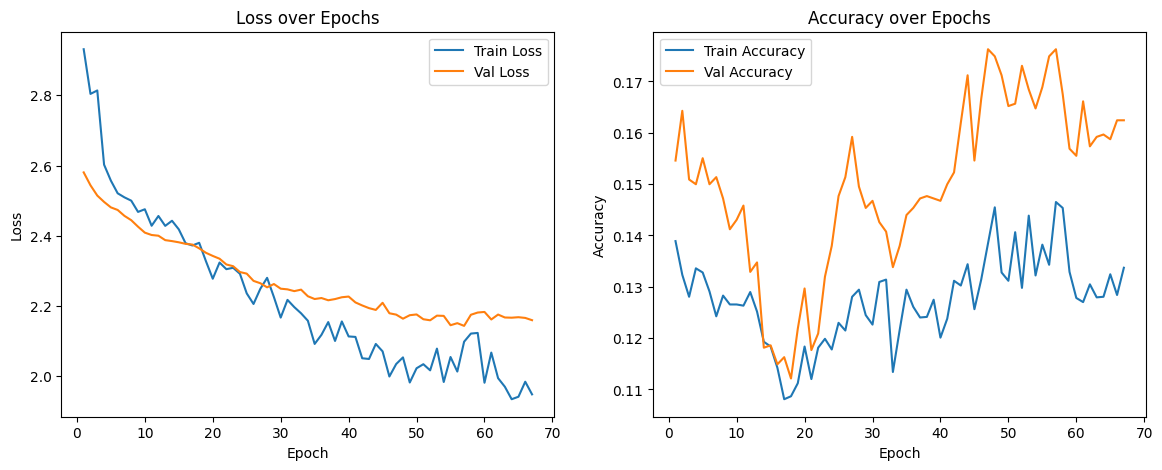

In [37]:
def plot_training_history(history):
    hist = history.history
    epochs_range = range(1, len(hist['loss']) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, hist['loss'], label='Train Loss')
    plt.plot(epochs_range, hist['val_loss'], label='Val Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, hist['accuracy'], label='Train Accuracy')
    plt.plot(epochs_range, hist['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.show()

plot_training_history(history)


In [38]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test Loss: {:.4f}".format(test_loss))
print("Test Accuracy: {:.2f}%".format(test_acc * 100))


Test Loss: 2.1437
Test Accuracy: 17.63%


68/68 [==============================] - 0s 1ms/step


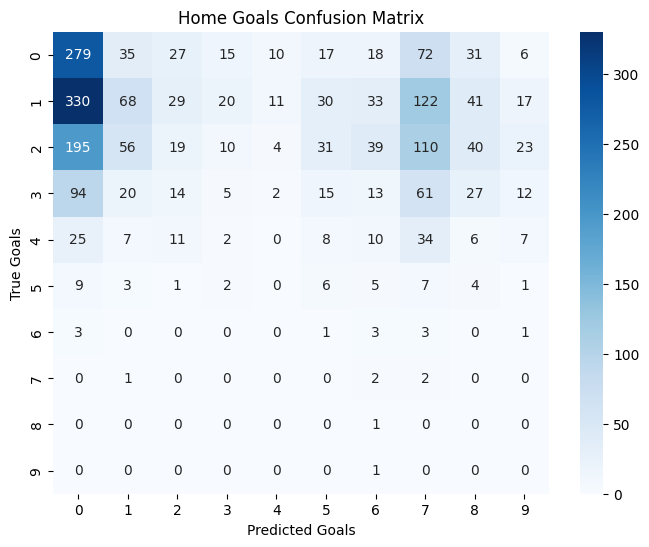

In [ ]:
# y_pred_probs = model.predict(X_test)
# y_pred = np.argmax(y_pred_probs, axis=1)

# cm = confusion_matrix(y_test, y_pred)
# print("Confusion Matrix:\n", cm)

# # For better visual clarity:
# plt.figure(figsize=(6, 4))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
#             xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
# plt.title("Confusion Matrix")
# plt.xlabel("Predicted")
# plt.ylabel("True")
# plt.show()

y_home = df['HomeGoals'].values  # Regression task

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # For classification

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=sorted(np.unique(y_home)),
            yticklabels=sorted(np.unique(y_home)))
plt.title("Home Goals Confusion Matrix")
plt.xlabel("Predicted Goals")
plt.ylabel("True Goals")
plt.show()

In [ ]:
# print("Classification Report:")
# print(classification_report(y_test, y_pred) )#, target_names=label_encoder.classes_))

target_names = [ 
    'FullTimeResults','HomeGoals','AwayGoals','StandingDiff', 'HomeWins', 'AwayWins',
    'AvgHomeGoals', 'AvgAwayGoals', 'AvgHomeGoalsConceded', 'AvgAwayGoalsConceded'
    ]
report = classification_report(
    y_test, 
    np.argmax(y_pred, axis=1), 
    target_names=target_names,
    digits=4  # Controls decimal precision
)

print("Classification Report:\n", report)

Classification Report:
                       precision    recall  f1-score   support

      FulTimeResults     0.2984    0.5471    0.3862       510
           HomeGoals     0.3579    0.0970    0.1526       701
           AwayGoals     0.1881    0.0361    0.0605       527
        StandingDiff     0.0926    0.0190    0.0315       263
            HomeWins     0.0000    0.0000    0.0000       110
            AwayWins     0.0556    0.1579    0.0822        38
        AvgHomeGoals     0.0240    0.2727    0.0441        11
        AvgAwayGoals     0.0049    0.4000    0.0096         5
AvgHomeGoalsConceded     0.0000    0.0000    0.0000         1
AvgAwayGoalsConceded     0.0000    0.0000    0.0000         1

            accuracy                         0.1763      2167
           macro avg     0.1021    0.1530    0.0767      2167
        weighted avg     0.2441    0.1763    0.1605      2167



In [59]:
new_data = df_matches.copy()

# Suppose new_data is a DataFrame with the same feature columns for future matches
new_data_scaled = scaler.transform(new_data[feature_cols].values)
predictions = model.predict(new_data_scaled)
predicted_classes = np.argmax(predictions, axis=1)

# Convert numeric predictions back to "H", "D", "A"
#predicted_FTR = label_encoder.inverse_transform(predicted_classes)
#new_data['Predicted_FTR'] = predicted_FTR
new_data['HomeGoals'] = predicted_classes

# save to csv
new_data.to_csv('g_results_predictions.csv', index=False)

print(new_data[['HomeTeam', 'AwayTeam', 'HomeGoals']])


339/339 [==============================] - 0s 1ms/step
          HomeTeam        AwayTeam  HomeGoals
0          Arsenal        Coventry          4
1      Aston Villa             QPR          2
2          Chelsea       Blackburn          4
3        Liverpool  Sheffield Weds          2
4         Man City           Leeds          2
...            ...             ...        ...
10830      Everton       Newcastle          0
10831       Wolves           Leeds          6
10832  Aston Villa         Arsenal          0
10833    Leicester       Brentford          8
10834    Tottenham        West Ham          5

[10835 rows x 3 columns]
